**“Since Google Colab does not support direct webcam access, object detection was demonstrated using uploaded images/videos while maintaining the same YOLOv8 inference pipeline.**

Install dependencies

In [1]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.0 MB/s eta 0:00:00


Upload an image

In [2]:
from google.colab import files
uploaded = files.upload()


Saving images (1).jpg to images (1).jpg


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


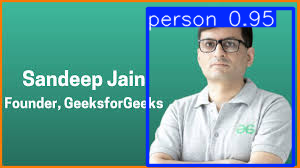

In [3]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load YOLOv8 model
model = YOLO('yolov8n.pt')

# Read uploaded image
image_path = list(uploaded.keys())[0]
frame = cv2.imread(image_path)

# Perform detection
results = model(frame, verbose=False)

# Annotate image
annotated_frame = results[0].plot()

# Display result
cv2_imshow(annotated_frame)


Upload a video

In [27]:
from google.colab import files

uploaded = files.upload()


Saving Dino_James_-_Jaane_De_Official_Teaser_720P.mp4 to Dino_James_-_Jaane_De_Official_Teaser_720P.mp4


Load YOLOv8 Model

In [28]:
from ultralytics import YOLO

# Load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

print("YOLOv8 model loaded successfully")


YOLOv8 model loaded successfully


# Object Detection with YOLOv8 in Google Colab

This notebook demonstrates how to perform object detection using the YOLOv8 model on both static images and video files within a Google Colab environment. It covers installing necessary libraries, uploading media, running the YOLOv8 model, and visualizing the detection results.

In [29]:
import cv2
import os

# Get uploaded video path (assuming 'uploaded' variable is still available)
video_path = list(uploaded.keys())[0]

# Define output directory and file
output_base_dir = "runs/detect"
custom_output_folder = "custom_output"
output_dir = os.path.join(output_base_dir, custom_output_folder)
os.makedirs(output_dir, exist_ok=True)
output_video_filename = "outputdino.mp4"
output_video_path = os.path.join(output_dir, output_video_filename)

# Open the input video file
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print(f"Error: Could not open video file {video_path}")
    raise IOError(f"Could not open video file {video_path}")

# Get video properties
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25.0 # Default to 25 FPS if not found

# Define the codec and create VideoWriter object
# For Colab, MP4V or XVID are usually good choices. FourCC for MP4V: 'mp4v'
fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Codec for .mp4 files
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

if not out.isOpened():
    print(f"Error: Could not open the output video file for writing at {output_video_path}")
    raise IOError(f"Could not open output video file {output_video_path}")

print(f"Processing video: {video_path}")
print(f"Saving output to: {output_video_path}")

frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Perform detection
    # model is loaded in cell W_uc6OZhl7ZO
    results = model(frame, verbose=False, conf=0.25)

    # Annotate frame
    annotated_frame = results[0].plot()

    # Write the annotated frame to the output video
    out.write(annotated_frame)
    frame_count += 1

print(f"Processed {frame_count} frames.")
# Release everything when job is finished
cap.release()
out.release()
print("Video processing completed and output saved.")

# Update the global variables for subsequent cells
output_folder = custom_output_folder # This will now be 'custom_output'
output_video_filename = "output.mp4" # This will be 'output.mp4'

print(f"Updated output_folder: {output_folder}")
print(f"Updated output_video_filename: {output_video_filename}")


Processing video: Dino_James_-_Jaane_De_Official_Teaser_720P.mp4
Saving output to: runs/detect/custom_output/outputdino.mp4
Processed 1554 frames.
Video processing completed and output saved.
Updated output_folder: custom_output
Updated output_video_filename: output.mp4


In [30]:
import os

print("Detect folder contents:")
os.listdir("runs/detect")


Detect folder contents:


['predict2', 'predict', 'custom_output']

In [31]:
import os

print("Output files in 'runs/detect/{output_folder}':")
print(os.listdir(f"runs/detect/{output_folder}"))


Output files in 'runs/detect/{output_folder}':
['output.mp4', 'outputdino.mp4']
